In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
#loading the dateset
df = pd.read_csv('/content/Mall_Customers.csv')

Conduct Exploratory Data Analysis (EDA)

In [6]:
#basic overview
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
#missing values
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
#duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


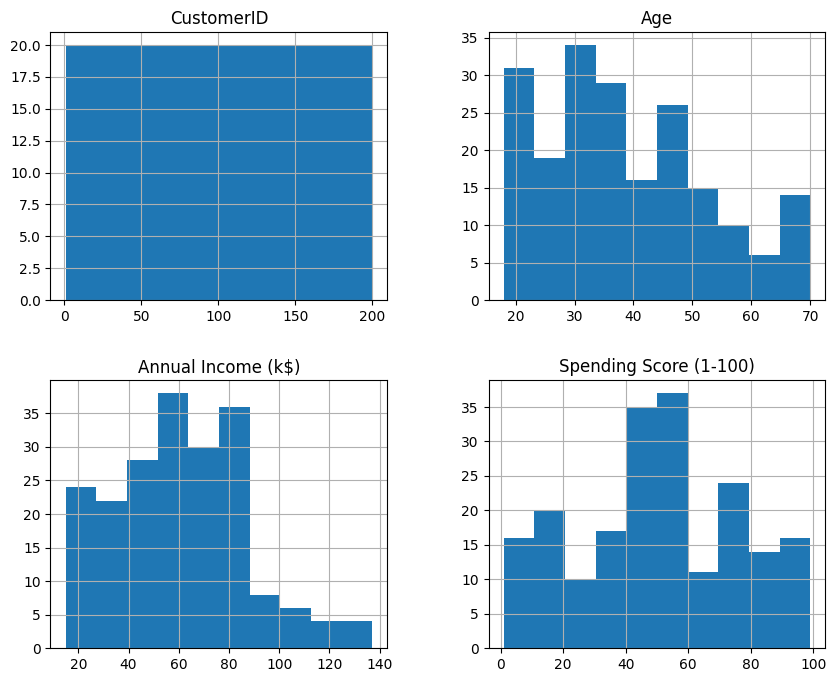

In [9]:
#histograms
df.hist(figsize=(10,8))
plt.show()

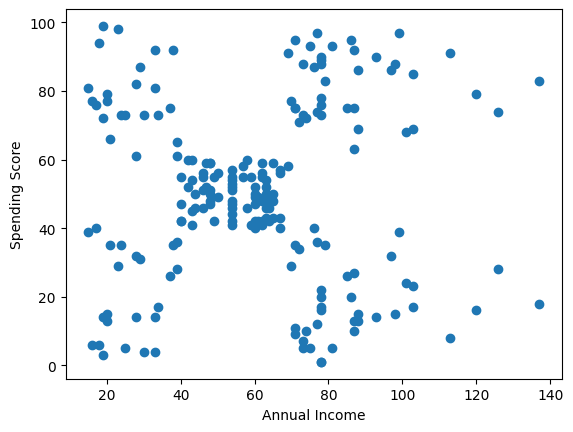

In [11]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

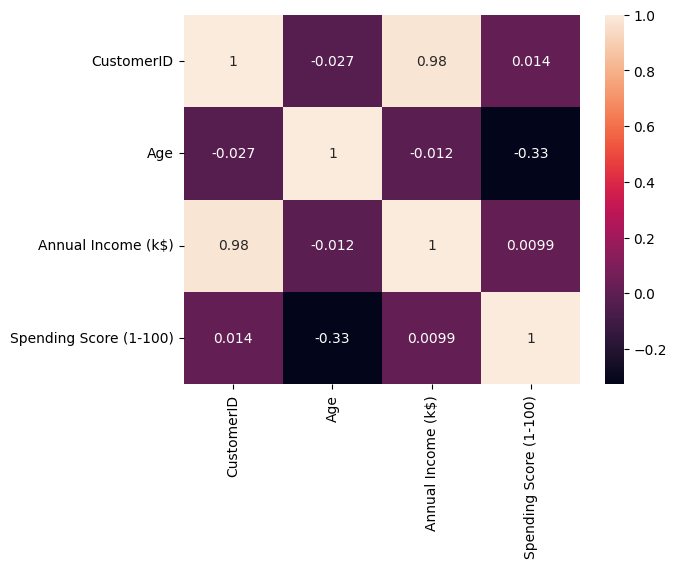

In [12]:
#correlation matrix
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

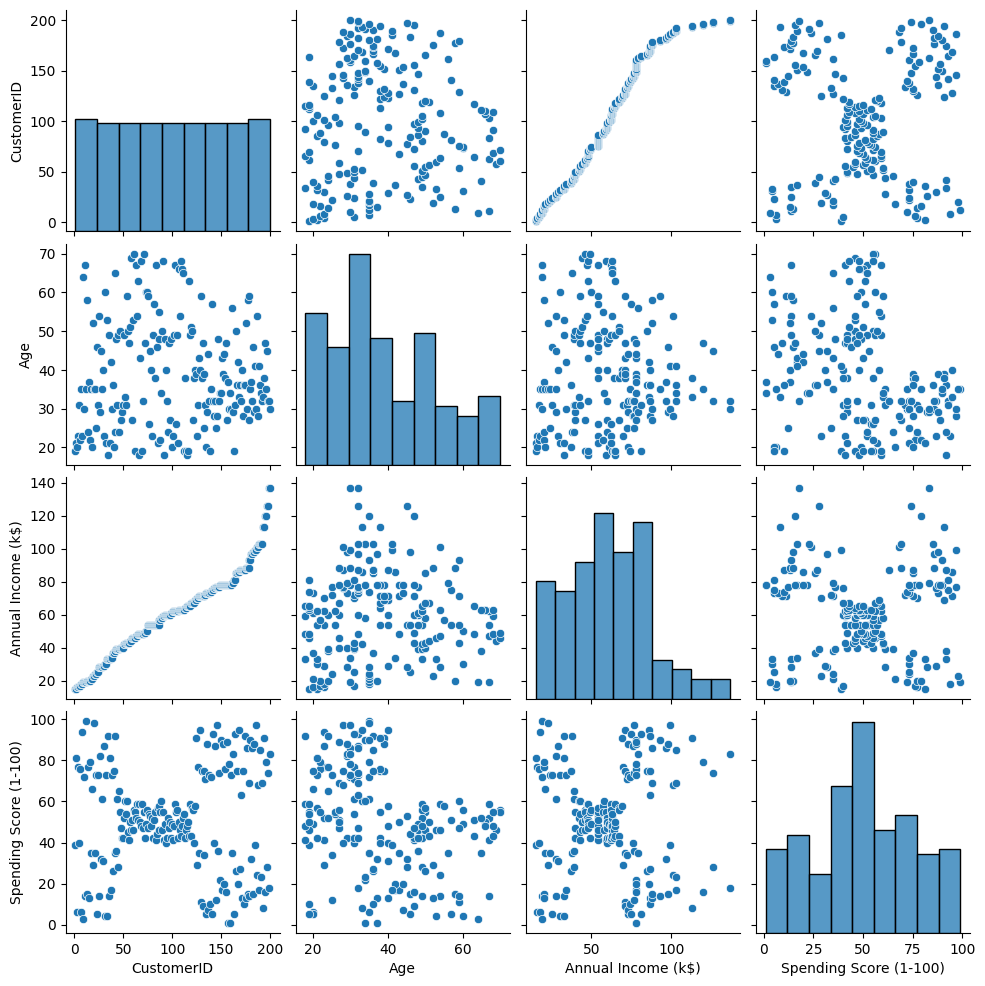

In [14]:
#pairplot
sns.pairplot(df)
plt.show()

Apply K-Means Clustering to segment customers

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

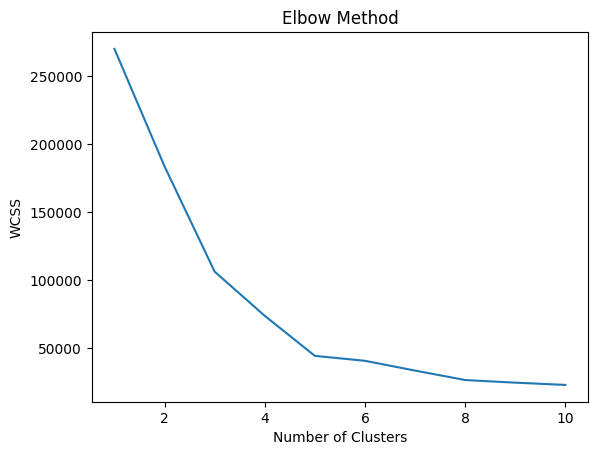

In [18]:
#elbow method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
#k means
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add cluster labels to dataset
df['Cluster'] = y_kmeans

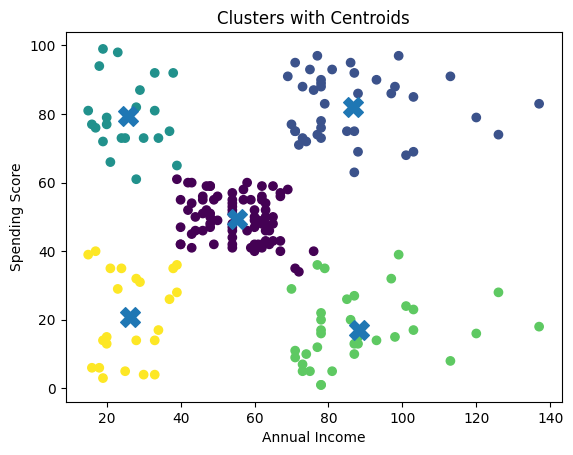

In [21]:
centers = kmeans.cluster_centers_
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y_kmeans)
plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X')  # centroids
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Centroids")
plt.show()

Use PCA or t-SNE to visualize the clusters

In [22]:
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

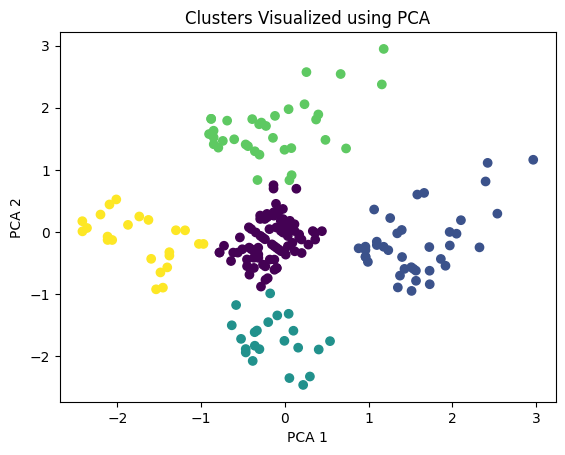

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters Visualized using PCA")
plt.show()

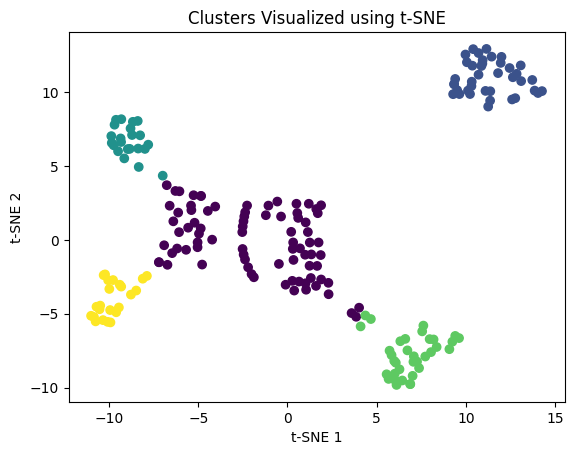

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['Cluster'])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Clusters Visualized using t-SNE")
plt.show()

## Suggest relevant marketing strategies for each identified segment

Customer segmentation allows businesses to target different groups effectively. High-income high-spending customers should be retained using premium services, while high-income low-spending customers should be encouraged to spend more through personalized offers. Low-income high-spending customers should be targeted with affordable deals, and low-income low-spending customers require activation through discounts. Average customers can be grown through general marketing and loyalty programs.